# IVON: sampling vs. Hutchinson (at-the-mean) estimates

This notebook compares the two estimators that produce the per-step gradient and
diagonal-Hessian estimates feeding the **same** IVON update on MNIST.

- **`estimator='sampling'`** (original IVON): draw posterior samples
  $\theta = \mu + \sigma\varepsilon$ and form reparameterization / Stein
  estimates,
  $\bar g = \tfrac1S\sum_s \nabla L(\theta_s)$ and
  $\bar h$ from $g\cdot\varepsilon/\sigma$. Controlled by `mc_samples` and
  `method` (`'sequential'` = scan, `'parallel'` = vmap).
- **`estimator='hutchinson'`** (variational Laplace, Sophia-style): evaluate at
  the mean $\mu$ — the gradient $\nabla L(\mu)$ and the diagonal Hessian via
  Hutchinson's estimator $u \odot (\nabla^2 L(\mu)\,u)$ with one Rademacher
  probe $u$, both obtained from a **single** forward-over-reverse pass
  (`jax.jvp` of `jax.value_and_grad`). `mc_samples` / `method` are ignored.

Only the estimates differ; the IVON state, momentum, Hessian EMA and
posterior-variance machinery are identical.

In [1]:
import os

# do not prealocate memory
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

# Set cuda device to use
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
try:
    import matplotlib.pyplot as plt
except:
    !pip install matplotlib
    import matplotlib.pyplot as plt
try:
    import seaborn as sns
except:
    !pip install seaborn
    import seaborn as sns

%matplotlib inline
sns.set_theme(context='notebook', style='white', color_codes=True)

In [3]:
import time

import jax
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
from blrax import ivon, get_scale

from data_loaders import load_mnist
from training import run_training

key = jr.PRNGKey(0)

## Data and metrics

Reused from `test_mnist.ipynb`.

In [4]:
train_ds, test_ds = load_mnist()

## Training loop

The same `run_training` as in `test_mnist.ipynb`, with one extra argument:
`estimator` is forwarded to `noisy_value_and_grad`. With
`estimator='hutchinson'` the `mc_samples` / `method` arguments are ignored.

In [5]:
def plot_performance(results, num_epochs):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)
    for name, vals in results.items():
        if vals is not None:
            for ax, lbl in zip(axes, ['acc', 'ece', 'nll']):
                ax.plot(range(1, num_epochs + 1), vals[lbl], 'o:', label=name)
                ax.set_xlabel('epoch')
                ax.set_title(lbl)
    axes[0].legend(title='estimator', fontsize=11)
    fig.tight_layout()
    return fig

## Model

In [6]:
depth = 5
in_size = 28 * 28
out_size = 10
num_neurons = 1024

NUM_EPOCHS = 30  # raise for sharper curves

key, _key = jr.split(key)
nnet = eqx.nn.MLP(in_size, out_size, num_neurons, depth, key=_key)
datasize = len(train_ds['image'])

## Train the two IVON variants

All runs share identical IVON hyper-parameters and start from the same network
weights; only the estimator (and its `mc_samples` / `method`) differs. We also
record wall-clock time per run (`jax.block_until_ready` forces the async compute
to finish before we stop the timer; the first epoch includes JIT compilation).

In [7]:
def make_optim(hess_init):
    return ivon(1e-2, ess=datasize, hess_init=hess_init, weight_decay=1e-4, clip_radius=1e-1)

configs = {
    'sampling (seq, mc=1)': dict(estimator='sampling', method='sequential', mc_samples=1, hess_init=0.35),
    'sampling (par, mc=4)': dict(estimator='sampling', method='parallel', mc_samples=4, hess_init=0.35),
    'hutchinson':           dict(estimator='hutchinson', hess_init=0.35),
}

results = {}
states = {}
timings = {}

for name, kw in configs.items():
    hess_init = kw.pop('hess_init')
    optim = make_optim(hess_init)
    key, _key = jr.split(key)
    t0 = time.time()
    _, final_opt_state, metrics = run_training(
        _key, nnet, optim, train_ds, test_ds, num_epochs=NUM_EPOCHS, **kw)
    metrics = jax.block_until_ready(metrics)
    dt = time.time() - t0

    results[name] = metrics
    states[name] = final_opt_state
    timings[name] = dt
    print(f"{name:22s} acc={float(metrics['acc'][-1]):.4f}  "
          f"nll={float(metrics['nll'][-1]):.4f}  ece={float(metrics['ece'][-1]):.4f}  "
          f"time={dt:.1f}s")

sampling (seq, mc=1)   acc=0.9802  nll=0.0902  ece=0.0006  time=13.4s
sampling (par, mc=4)   acc=0.9799  nll=0.0896  ece=0.0006  time=20.2s
hutchinson             acc=0.9786  nll=0.0963  ece=0.0006  time=19.5s


## Convergence: accuracy, calibration (ECE), NLL

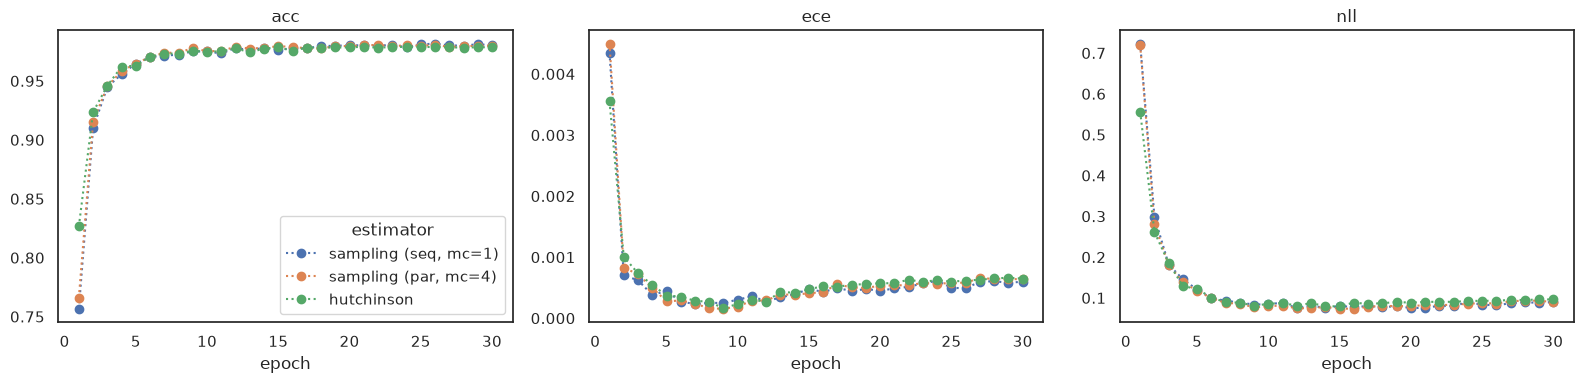

In [8]:
fig = plot_performance(results, NUM_EPOCHS)

## Cost per run

`hutchinson` does a single forward-over-reverse pass — one gradient **and** one
Hessian-vector product — independent of `mc_samples`. The sampling estimator
costs roughly one gradient evaluation per Monte-Carlo sample, so its compute
grows with `mc_samples`.

On this small MLP the absolute differences are tiny and dominated by JIT-compile
and dispatch overhead (all runs are within ~1-2 s, and `mc=4` can even clock in
below `mc=1` because the vmap keeps the GPU busier), so read the bars
qualitatively. The cost gap in favour of `hutchinson` widens as `mc_samples`
and model size grow.

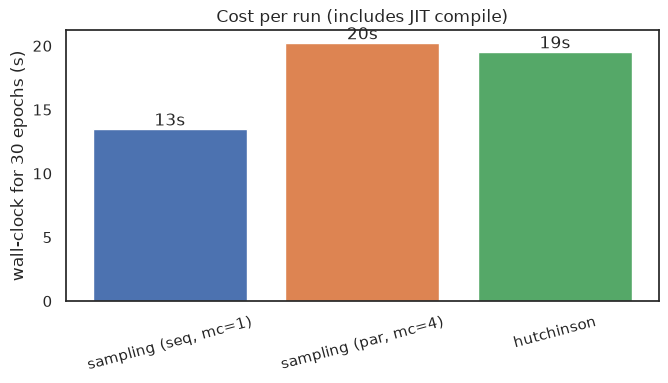

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
names = list(timings.keys())
ax.bar(names, [timings[n] for n in names], color=sns.color_palette()[:len(names)])
ax.set_ylabel(f'wall-clock for {NUM_EPOCHS} epochs (s)')
ax.set_title('Cost per run (includes JIT compile)')
for i, n in enumerate(names):
    ax.text(i, timings[n], f"{timings[n]:.0f}s", ha='center', va='bottom')
plt.xticks(rotation=15)
fig.tight_layout()

## Learned posterior uncertainty

IVON's posterior std is $\sigma = 1/\sqrt{\mathrm{ess}\,(h + \lambda)}$
(`get_scale`). The two estimators drive `h` differently, so the learned
uncertainty over weights differs.

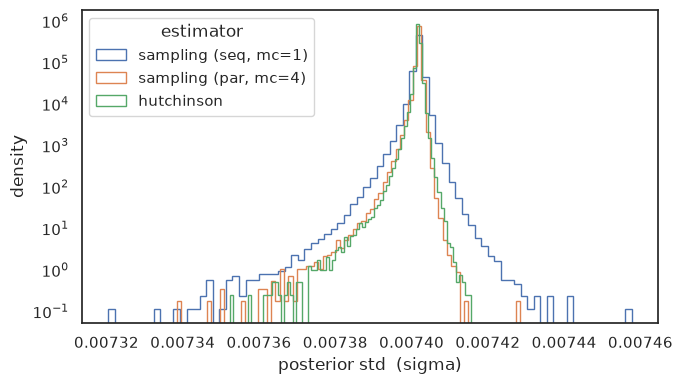

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
for name, final_opt_state in states.items():
    scale = get_scale(final_opt_state[0])
    flat = jnp.concatenate([jnp.ravel(v) for v in jax.tree.leaves(scale)])
    ax.hist(flat, bins=80, histtype='step', density=True, label=name)
ax.set_xlabel('posterior std  (sigma)')
ax.set_ylabel('density')
ax.set_yscale('log')
ax.legend(title='estimator', fontsize=11)
fig.tight_layout()

## Takeaways

- **Same optimizer, different estimates.** Both variants share IVON's update;
  they differ only in how `(g_bar, h_bar)` are produced each step.
- **`hutchinson` is deterministic at the mean** (variational Laplace): one
  Rademacher probe gives an unbiased diagonal-Hessian estimate via a single
  `jvp(value_and_grad)` pass. It needs no posterior sampling and ignores
  `mc_samples` / `method`.
- **Variance / cost trade-off.** Sampling with larger `mc_samples` reduces
  estimator variance at linear cost; `hutchinson` fixes the cost at ~one
  gradient + one HVP and removes the self-term variance of the diagonal
  estimate (Rademacher probes).
- Compare the accuracy / ECE / NLL curves, the wall-clock bars, and the
  posterior-std histograms above to see how the choice plays out on MNIST.